Biblioteca

In [ ]:

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from keras import Model
from keras.models import Sequential
from keras.losses import categorical_crossentropy
from keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout
from sklearn.model_selection import train_test_split
from keras import datasets
from keras.utils import to_categorical
import random
from __future__ import absolute_import, division, print_function, unicode_literals


Keras contine un conjunto de Datasets. en tre ellos fashion_mnist.

preparación de los datos

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()   #cargamos los datos


x_train = x_train.astype('float32')     #Convertimos a flotantes (float32) 
x_test = x_test.astype('float32')       #Convertimos a flotantes (float32)

# normalización de los datos
x_train /= 255      # 225 es el valor máximo de pixeles
x_test /= 255

# reshape de los datos para que sean compatibles con la red neuronal
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)  
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

x_train, x_val, y_train, y_val = train_test_split(
    x_train, 
    y_train, 
    test_size=10000, # 1/6 del total de entrenamiento (fashion mnist contiene en total de 60,000 imagenes de entrenamiento)
    random_state=42, 
    stratify=y_train
)

# one-hot encoding de las etiquetas
y_train = to_categorical(y_train, 10)
y_val = to_categorical(y_val, 10)
y_test = to_categorical(y_test, 10)


procedemos a construir la red neuronal convolucional utilizando Keras.

In [15]:
# construcción del modelo de red neuronal convolucional
model = Sequential()

# convolución 1
model.add(Conv2D(32,                        # número de filtros
                 kernel_size=(3, 3),        # tamaño del kernel
                 activation='relu',         # función de activación
                 input_shape=(28, 28, 1),   # forma de los datos de entrada
                 padding='same'))           # relleno

# pooling 1
model.add(MaxPool2D(pool_size=(2, 2)))   # capa de pooling para reducir la dimensionalidad

# convolución 2
model.add(Conv2D(64, 
                 kernel_size=(3, 3),            # número de filtros
                 padding='same',                # relleno
                 activation='relu'))            # función de activación

# pooling 2
model.add(MaxPool2D(pool_size=(2, 2)))   # capa de pooling para reducir la dimensionalidad

# aplanamiento
model.add(Flatten())                            # aplanar los datos para la capa densa

# capa densa
model.add(Dense(128,                            # número de neuronas
                activation='relu'))             # capa densa con 128 neuronas y función de activación ReLU

model.add(Dropout(0.5))                         # capa de dropout para evitar el sobre-ajuste

model.add(Dense(10,                         # número de neuronas
                activation='softmax'))      # capa densa con 10 neuronas y función de activación softmax 

Compilación del modelo

In [ ]:
lr = 0.001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


# resumen del modelo
model.summary()
# entrenamiento del modelo
history = model.fit(x_train, y_train, epochs=23, batch_size=128, validation_data=(x_val, y_val))

# evaluación del modelo
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/23
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.7895 - loss: 0.5909 - val_accuracy: 0.8614 - val_loss: 0.3760
Epoch 2/23
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.8645 - loss: 0.3824 - val_accuracy: 0.8849 - val_loss: 0.3232
Epoch 3/23
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.8825 - loss: 0.3277 - val_accuracy: 0.8882 - val_loss: 0.3008
Epoch 4/23
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.8928 - loss: 0.2966 - val_accuracy: 0.8925 - val_loss: 0.2888
Epoch 5/23
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9007 - loss: 0.2739 - val_accuracy: 0.9067 - val_loss: 0.2555
Epoch 6/23
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9069 - loss: 0.2541 - val_accuracy: 0.9106 - val_loss: 0.2447
Epoch 7/23
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.9121 - loss: 0.2393 - val_accuracy: 0.9129 - val_loss: 0.2396
Epoch 8/23
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9202 - loss: 0.2225 - 

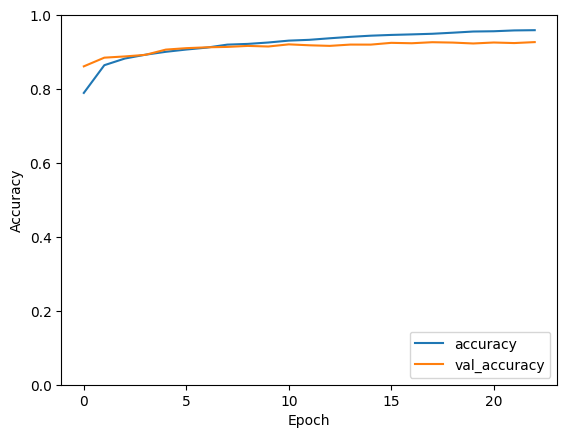

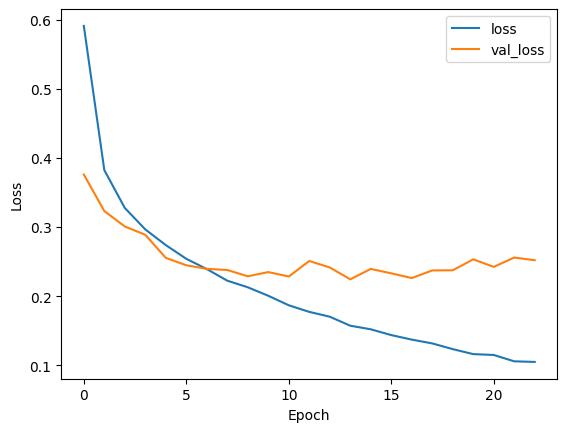

In [17]:

# visualización de los resultados
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()
